In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from datetime import datetime
import matplotlib.pyplot as plt


In [20]:
# ------------------------------
# CONFIG
# ------------------------------
PV_CSV_PATH = "pv_data.csv"  # change to your csv filename
WEATHER_CSV_PATH = "weather_data.csv"
TIME_COL = "timestamp"

In [21]:
TARGET_COL = "soc"
ALL_FEATURES = ["soc","load","pv","sun_hours","temperature","glob_radiation_wm2", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "woy_sin","woy_cos"]
PAST_FEATURES = ["soc","load","pv", "sun_hours","temperature", "glob_radiation_wm2", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "woy_sin","woy_cos"]#
EXOG_FEATURES = ["temperature","sun_hours", "glob_radiation_wm2", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "woy_sin","woy_cos"]#

In [22]:
# ==== 1. Load PV data (5-min intervals) ====

# Parse timestamp index, ensure timezone-naive for alignment
pv_df = pd.read_csv(
    PV_CSV_PATH,
    sep=",",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

# Convert numeric
pv_df = pv_df.apply(pd.to_numeric, errors="coerce")

# ==== 2. Resample PV data to hourly ====
# Average SOC, PV, and Load over each hour
pv_hourly = pv_df.resample("1h").mean()

# ==== 3. Load weather data (already hourly) ====
weather_df = pd.read_csv(
    WEATHER_CSV_PATH,
    sep=",",
    parse_dates=["time"],
    index_col="time"
)

# Convert timezone-aware → naive UTC or local
if weather_df.index.tz is not None:
    weather_df.index = weather_df.index.tz_convert(None)

# Ensure numeric dtype
weather_df = weather_df.apply(pd.to_numeric, errors="coerce")

# ==== 4. Align start dates and merge ====
# Filter weather data starting from 2024-07-01
weather_df = weather_df.loc["2024-07-01":"2025-10-20"]

# Join on timestamp/hour
df = pv_hourly.join(weather_df, how="inner")

# --- Add time features ---
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["weekofyear"] = df.index.isocalendar().week

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["woy_sin"] = np.sin(2 * np.pi * df["weekofyear"] / 52)
df["woy_cos"]= np.cos(2 * np.pi * df["weekofyear"] / 52)

df = df[ALL_FEATURES]

# ==== 5. Optional sanity checks ====
print("Merged shape:", df.shape)
print(df.head(5))
print(df.tail(5))

# Check for missing values
missing = df.isna().sum()
print("\nMissing values per column:\n", missing)

df = df.replace(["None", "nan", "NaN", ""], pd.NA)
df = df.ffill().bfill()

df.info()

Merged shape: (11448, 12)
                           soc      load   pv  sun_hours  temperature  \
2024-07-01 00:00:00  69.583333  0.191667  0.0        0.0         20.8   
2024-07-01 01:00:00  66.916667  0.205000  0.0        0.0         20.8   
2024-07-01 02:00:00  64.083333  0.191667  0.0        0.0         20.5   
2024-07-01 03:00:00  61.500000  0.203333  0.0        0.0         20.2   
2024-07-01 04:00:00  58.916667  0.208333  0.0        0.0         20.1   

                     glob_radiation_wm2  hour_sin  hour_cos  dow_sin  dow_cos  \
2024-07-01 00:00:00                   0  0.000000  1.000000      0.0      1.0   
2024-07-01 01:00:00                   0  0.258819  0.965926      0.0      1.0   
2024-07-01 02:00:00                   0  0.500000  0.866025      0.0      1.0   
2024-07-01 03:00:00                   0  0.707107  0.707107      0.0      1.0   
2024-07-01 04:00:00                  18  0.866025  0.500000      0.0      1.0   

                      woy_sin   woy_cos  
2024-0

In [23]:
# --- Split sets ---
split_train = int(len(df) * 0.7)
split_val = int(len(df) * 0.85)
df_train = df.iloc[:split_train]
df_val = df.iloc[split_train:split_val]
df_test = df.iloc[split_val:]

# --- Fit scalers ---
scaler_soc = StandardScaler()
scaler_X = StandardScaler()
scaler_exog = StandardScaler()

scaler_soc.fit(df_train[[TARGET_COL]])
scaler_X.fit(df_train[PAST_FEATURES])
scaler_exog.fit(df_train[EXOG_FEATURES])

# --- Apply scaling ---
df_scaled = pd.DataFrame(index=df.index)
df_scaled[TARGET_COL] = scaler_soc.transform(df[[TARGET_COL]]).flatten()
df_scaled[PAST_FEATURES] = scaler_X.transform(df[PAST_FEATURES])
df_scaled[EXOG_FEATURES] = scaler_exog.transform(df[EXOG_FEATURES])

# Final check
print("Scaled min/max (soc):", df_scaled["soc"].min(), df_scaled["soc"].max())
print("Scaled sample:\n", df_scaled.head())

Scaled min/max (soc): -0.944270287351143 1.6073455658111448
Scaled sample:
                           soc      load        pv  sun_hours  temperature  \
2024-07-01 00:00:00  0.831229 -0.505614 -0.456673   -0.58851     1.082244   
2024-07-01 01:00:00  0.763186 -0.495285 -0.456673   -0.58851     1.082244   
2024-07-01 02:00:00  0.690890 -0.505614 -0.456673   -0.58851     1.048922   
2024-07-01 03:00:00  0.624973 -0.496577 -0.456673   -0.58851     1.015599   
2024-07-01 04:00:00  0.559057 -0.492703 -0.456673   -0.58851     1.004491   

                     glob_radiation_wm2  hour_sin  hour_cos   dow_sin  \
2024-07-01 00:00:00           -0.615907 -0.000259  1.414782 -0.007683   
2024-07-01 01:00:00           -0.615907  0.365736  1.366590 -0.007683   
2024-07-01 02:00:00           -0.615907  0.706788  1.225298 -0.007683   
2024-07-01 03:00:00           -0.615907  0.999656  1.000534 -0.007683   
2024-07-01 04:00:00           -0.529830  1.224382  0.707615 -0.007683   

                      

                          soc      load        pv  sun_hours  temperature  \
2024-07-01 00:00:00  0.831229 -0.505614 -0.456673   -0.58851     1.082244   
2024-07-01 01:00:00  0.763186 -0.495285 -0.456673   -0.58851     1.082244   
2024-07-01 02:00:00  0.690890 -0.505614 -0.456673   -0.58851     1.048922   
2024-07-01 03:00:00  0.624973 -0.496577 -0.456673   -0.58851     1.015599   
2024-07-01 04:00:00  0.559057 -0.492703 -0.456673   -0.58851     1.004491   

                     glob_radiation_wm2  hour_sin  hour_cos   dow_sin  \
2024-07-01 00:00:00           -0.615907 -0.000259  1.414782 -0.007683   
2024-07-01 01:00:00           -0.615907  0.365736  1.366590 -0.007683   
2024-07-01 02:00:00           -0.615907  0.706788  1.225298 -0.007683   
2024-07-01 03:00:00           -0.615907  0.999656  1.000534 -0.007683   
2024-07-01 04:00:00           -0.529830  1.224382  0.707615 -0.007683   

                      dow_cos   woy_sin   woy_cos  
2024-07-01 00:00:00  1.413225 -0.139714 -1.605

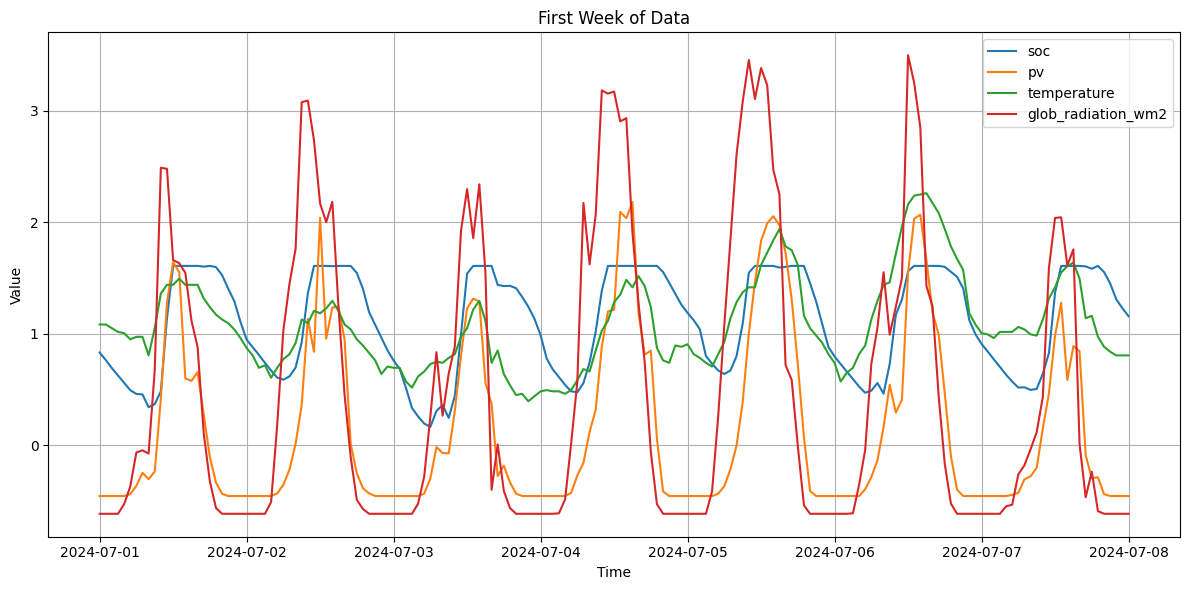

In [24]:
import matplotlib.pyplot as plt

# Select the first week of available data
first_week = df_scaled.loc[df_scaled.index[0] : df_scaled.index[0] + pd.Timedelta(days=7)]

# Print the subset to verify
print(first_week.head())

# Choose a few key columns to visualize
cols_to_plot = ["soc","pv", "temperature", "glob_radiation_wm2"]  # adjust names to your actual columns

# Plot
plt.figure(figsize=(12, 6))
for col in cols_to_plot:
    if col in first_week.columns:
        plt.plot(first_week.index, first_week[col], label=col)

plt.title("First Week of Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
